In [72]:
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END, StateGraph
from langgraph.types import Send
from pydantic import BaseModel, Field
from typing import TypedDict, List, Annotated
from operator import add
from dotenv import load_dotenv

# ----------------------------
# Load environment variables
# ----------------------------
load_dotenv()

# ----------------------------
# Initialize LLM
# ----------------------------
llm = ChatOpenAI(model="gpt-4o-mini")


# ----------------------------
# Pydantic Model
# ----------------------------
class SubTasks(BaseModel):
    sub_topics: List[str] = Field(description="List of sub topics (max 5)")


# ----------------------------
# State Definitions
# ----------------------------
class MainState(TypedDict):
    topic: str
    sub_topics: List[str]
    articles: Annotated[List[str], add]
    final_output : str


class WorkerState(TypedDict):
    topic: str
    sub_topic: str
    articles: Annotated[List[str], add]


# ----------------------------
# Nodes
# ----------------------------

def divide_task(state: MainState):
    """Break main topic into subtopics"""

    prompt = f"""
    You are an expert content strategist.

    Break the topic below into subtopics.

    Topic:
    {state['topic']}

    Requirements:
    - Maximum of 5 subtopics
    - Each must be clear and distinct
    - Keep them short (phrases, not sentences)
    """

    structured_llm = llm.with_structured_output(SubTasks)
    response = structured_llm.invoke(prompt)

    print("\nMain Topic:", state["topic"])
    print("Subtopics:")
    print("- " + "\n- ".join(response.sub_topics))

    return {
        "sub_topics": response.sub_topics
    }


# ----------------------------
# Fan-out Routing
# ----------------------------
def route_to_workers(state: MainState):
    """Send each subtopic to a worker"""

    if not state.get("sub_topics"):
        return []

    return [
        Send(
            "worker",
            {
                "topic": state["topic"],
                "sub_topic": topic
            }
        )
        for topic in state["sub_topics"]
    ]


# ----------------------------
# Worker Node
# ----------------------------
def worker_node(state: WorkerState):
    """Process a single subtopic"""

    prompt = f"""
    Generate content for the subtopic below.

    Main Topic: {state['topic']}
    Subtopic: {state['sub_topic']}

    Instructions:
    - Keep it simple and clear
    - 150–200 words
    - Use examples where helpful
    """

    result = llm.invoke(prompt).content

    print(f" generating Sub topic: {state['sub_topic']}...")
    # print(result,'\n\n\n')
  


    return {
        "articles": [result]
    }


# ----------------------------
# Combine Node
# ----------------------------


def combine_node(state: MainState):
    """ Combine all the articles together"""

    articles_count = len(state['sub_topics'])
    if not articles_count:
        return f"No articles generated for {state['topic']}"
    
    all_aritcles = f"\n\n TOPIC:\n{state['topic'].upper()}\n{'='*len(state['topic'])}"
    
    #combine the articles together
    for subtopic, content in zip(state['sub_topics'], state['articles']):
        all_aritcles +=f""" 
\n\n
{subtopic}
{'='*len(subtopic)}
{content}
        """
    
    return {
        "final_output": all_aritcles
    }
        





In [73]:
# ----------------------------
# Build Graph
# ----------------------------
builder = StateGraph(MainState)

# Add nodes
builder.add_node("divide", divide_task)
builder.add_node("worker", worker_node)
builder.add_node("combine", combine_node)

# Flow
builder.add_edge(START, "divide")

# Fan-out
builder.add_conditional_edges(
    "divide",
    route_to_workers
)

# Fan-in (aggregation happens automatically)
builder.add_edge("worker", "combine")

# Final step
builder.add_edge("combine", END)

# Compile graph
graph = builder.compile()



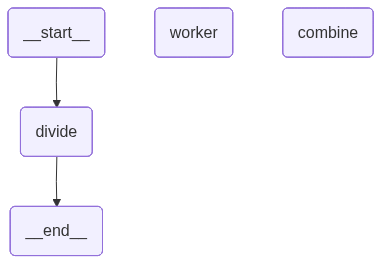

In [70]:
graph

In [74]:

# ----------------------------
# Run Example
# ----------------------------
topic = "Artificial Intelligence in Healthcare"

result = graph.invoke({
    "topic": topic
})

print("\n--- FINAL OUTPUT ---\n")
print(result.get('final_output',''))

c:\lang1\venvi\Lib\site-packages\pydantic\main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=SubTasks(sub_topics=['AI ...of AI on Patient Care']), input_type=SubTasks])
  return self.__pydantic_serializer__.to_python(



Main Topic: Artificial Intelligence in Healthcare
Subtopics:
- AI Applications in Diagnostics
- AI in Personalized Medicine
- Ethical Considerations in AI Healthcare
- AI for Healthcare Data Management
- Impact of AI on Patient Care
 generating Sub topic: AI Applications in Diagnostics...
 generating Sub topic: Impact of AI on Patient Care...
 generating Sub topic: Ethical Considerations in AI Healthcare...
 generating Sub topic: AI in Personalized Medicine...
 generating Sub topic: AI for Healthcare Data Management...

--- FINAL OUTPUT ---



 TOPIC:
ARTIFICIAL INTELLIGENCE IN HEALTHCARE



AI Applications in Diagnostics
**AI Applications in Diagnostics**

Artificial intelligence (AI) is transforming diagnostics in healthcare by improving accuracy and speed. One of the most notable applications is in imaging analysis. For instance, AI algorithms can analyze medical images, such as X-rays, MRIs, and CT scans, to identify conditions like tumors or fractures. Companies like Zebra Medica

In [ ]:
# def combine_node(state: MainState):
#     """Combine all generated outputs into one final article"""

#     # Collect outputs from workers
#     all_sections = state.get("final_output", [])

#     combined_text = "\n\n".join(all_sections)

#     final_prompt = f"""
#     Combine the following sections into a well-structured article.

#     {combined_text}

#     Instructions:
#     - Add a short introduction
#     - Ensure smooth flow between sections
#     - Add a conclusion
#     """

#     final_article = llm.invoke(final_prompt).content

#     return {
#         "final_output": [final_article]
#     }

boy
girl
man
woman
son
daughter
